# Observation des lignes de courant de vent — large300 (Méso-NH RCE)

**Objectif** On a montré que paramétriser le flux de Reynolds $\rho_0\langle u'w'\rangle$ par le seul flux de masse (bulk-plume) est insuffisant : le résidu sous-maille $T_2$ est irréductible ($\sim 44\%$) et structurellement corrélé au flux total. 

**Nouvelle piste.** Regarder directement la *structure spatiale* de l'écoulement via les **lignes de courant** dans le plan $(x,z)$, coupe moyennée sur $y$, et la **confronter à la corrélation** $u'w'$.

---
### Trame 
1. **Calcul de la fonction de courant** $\psi$ (isolignes) — convention de masse anélastique.
2. **Coupe verticale moyennée sur $y$** à $t$ donné (et moyenne temporelle).
3. **Comment voit-on la faible corrélation $u'w'$ ?** — superposer streamlines et carte de $u'w'$.
4. **Que tirer de la visualisation ?** — diagnostics quantitatifs.
5. **Lien avec la paramétrisation du flux de Reynolds.**
6. **Décomposition du courant en ondelettes / Fourier** — échelles dominantes.
7. **Extension aux lignes de courant 3D.**
8. **Isolation des tourbillons** (critère $\lambda_2$ / vorticité / Okubo-Weiss).
9. **Autres idées** 

#  Les lignes de courant

À un instant donné, en chaque point de l'espace, le vent est un **vecteur** $\vec{V}=(u,w)$ (ici dans le plan vertical $(x,z)$). Une **ligne de courant** (*streamline*) est une courbe qui est, partout, **tangente à ce vecteur vitesse**.

Tracer des lignes tangentes au champ « à la main » serait pénible. Il existe un **raccourci mathématique** très puissant, à une condition.

**La condition : un écoulement incompressible (sans création ni perte de matière).** En 2D, cela s'écrit « la divergence est nulle » :
$$\frac{\partial u}{\partial x} + \frac{\partial w}{\partial z} = 0.$$

**Le théorème.** Quand cette condition est vraie, il existe une **fonction scalaire** $\psi(x,z)$ — un simple nombre attaché à chaque point — telle que les deux composantes de la vitesse sont ses dérivées :
$$u = -\frac{\partial \psi}{\partial z}, \qquad w = +\frac{\partial \psi}{\partial x}.$$
Cette $\psi$ s'appelle la **fonction de courant**.

 On peut vérifier que le long d'une courbe où $\psi$ reste constant, le déplacement est exactement tangent à $\vec V$. Autrement dit :
$$\boxed{\text{les lignes de courant} = \text{les lignes de niveau (isolignes) de } \psi.}$$
Tracer les lignes de courant revient donc à tracer un simple **contour** de $\psi$ (comme les courbes de niveau d'une carte topographique). Un `plt.contour(psi)` suffit.

Bonus : la **différence de $\psi$** entre deux lignes donne le **débit** qui passe entre elles. Resserrement des isolignes ⇔ écoulement intense.

---
## Étape 3 — Le cas de l'atmosphère : fonction de courant **de masse**

L'air n'est pas incompressible : sa densité $\rho_0(z)$ **chute avec l'altitude** (l'air est plus dense en bas). La divergence de la vitesse n'est donc pas nulle.

**La bonne quantité conservée** n'est pas le volume mais la **masse**. L'approximation *anélastique* (standard en convection) dit que c'est le **flux de masse** $(\rho_0 u,\ \rho_0 w)$ qui est sans divergence :
$$\frac{\partial (\rho_0\, u)}{\partial x} + \frac{\partial (\rho_0\, w)}{\partial z} = 0.$$
On définit alors une **fonction de courant de masse** $\psi$ par :
$$\rho_0\, u = -\frac{\partial \psi}{\partial z}, \qquad \rho_0\, w = +\frac{\partial \psi}{\partial x}.$$
Ses isolignes sont les lignes de courant du **transport de masse** — exactement ce qui décrit la circulation de retournement (*overturning*) de la convection.

---
## Étape 4 — Pourquoi pas une simple intégration ? (le piège)

Naïvement, on pourrait obtenir $\psi$ en **intégrant** : par exemple, partir de $w = \frac{1}{\rho_0}\partial_x\psi$ et cumuler $\psi(x,z) = \int_0^x \rho_0\, w\,dx'$.

**Le problème :** cette recette suppose que la condition de divergence nulle est *parfaitement* vérifiée. Or nos données réelles ne le sont jamais exactement : on a moyenné sur un $y$ de taille finie, il y a du bruit turbulent, et la grille est discrète. Du coup :
- intégrer **horizontalement** ($\int \rho_0 w\, dx$) ou **verticalement** ($-\int \rho_0 u\, dz$) donne **deux résultats différents** ;
- le résultat **dépend du chemin** suivi pour intégrer. Ce n'est pas acceptable.

---
## Étape 5 — La solution propre : décomposition de Helmholtz + équation de Poisson

Tout champ de vecteurs se décompose de façon unique (théorème de **Helmholtz**) en deux morceaux :
$$\text{flux de masse} = \underbrace{\text{partie rotationnelle}}_{\text{tourne, porte la circulation}} + \underbrace{\text{partie divergente}}_{\text{source/puits, pas de circulation}}.$$
Seule la **partie rotationnelle** correspond à une vraie fonction de courant. On veut donc l'extraire proprement et **jeter** le reste.

Pour cela on introduit la **vorticité** (le « taux de rotation local » de l'écoulement). En appliquant l'opérateur rotationnel à la définition de $\psi$, les deux relations $\rho_0 u=-\partial_z\psi$ et $\rho_0 w=+\partial_x\psi$ se combinent en **une seule équation** :
$$\boxed{\nabla^2\psi \;=\; \frac{\partial(\rho_0 w)}{\partial x} - \frac{\partial(\rho_0 u)}{\partial z}}$$
où $\nabla^2 = \partial_x^2 + \partial_z^2$ est le **Laplacien**. C'est une **équation de Poisson** : le membre de droite (calculable directement à partir des données $u,w$) est connu, et on cherche $\psi$.

**Comment on la résout numériquement ?**
1. On calcule le membre de droite (la vorticité de masse) par différences finies.
2. On écrit le Laplacien comme une grande **matrice creuse** (chaque point relié à ses 4 voisins).
3. On impose une **condition au bord** : ici $\psi=0$ sur le contour du domaine (Dirichlet). *(À adapter en périodique si le domaine l'est — voir remarque en fin de notebook.)*
4. On résout le système linéaire $A\,\psi = b$ en une fois (`scipy.sparse.linalg.spsolve`).

**Le résultat** est un $\psi$ **unique** et **indépendant du chemin** : la résolution projette automatiquement le champ sur sa partie rotationnelle et laisse de côté la partie divergente.

---
###  Résumé
> Une ligne de courant est une isoligne de la fonction de courant $\psi$ ; en atmosphère on travaille avec $\psi$ **de masse** ($\rho_0 u=-\partial_z\psi$, $\rho_0 w=+\partial_x\psi$) ; et pour l'obtenir proprement sur des données réelles on **résout une équation de Poisson** $\nabla^2\psi=\partial_x(\rho_0 w)-\partial_z(\rho_0 u)$ plutôt que d'intégrer naïvement.

## 0. Imports & configuration

Calé sur le pipeline **large300** : fichiers 3D séparés par variable dans `3D/MESONH_RCE_large300_3D_{var}.nc` (variables `ua`,`va`,`wa`,`ta`,`pa`,`hus`), altitude reprise du 1D, état stationnaire = **dernier tiers** des pas de temps, $\rho_0(z)$ calculé via la température virtuelle. Lecture **niveau par niveau** pour la RAM.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import xarray as xr
import gc, os

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11,
    'axes.grid': True, 'grid.alpha': 0.25,
    'image.cmap': 'RdBu_r',
})

# ============================================================
#  CONFIGURATION  (identique au notebook rcemip_large300)
# ============================================================
DIR_3D = '3D';  DIR_2D = '2D';  DIR_1D = '1D'
def path3d(var): return os.path.join(DIR_3D, f'MESONH_RCE_large300_3D_{var}.nc')
def path1d(var): return os.path.join(DIR_1D, f'MESONH_RCE_large300_1D_{var}.nc')

Rd, Rv = 287.05, 461.5
EPSILON = Rd / Rv          # ≈ 0.622
BLOC    = 2                # taille de bloc temporel (RAM)

USE_SYNTHETIC = False      # True = champ jouet (démo sans données) ; False = large300

# Résolution horizontale large300 (mêmes valeurs que le pipeline rcemip).
# Forcée à 2000 m si les coordonnées sont des indices entiers.
DX_DEFAULT = 1000.0        # m

print('Config prête. USE_SYNTHETIC =', USE_SYNTHETIC)

Config prête. USE_SYNTHETIC = False


## 1. Chargement large300 : coupe $(x,z)$ moyennée sur $y$ et sur le temps

On construit la coupe 2D $(z,x)$ en moyennant **sur $y$** (révèle l'overturning) **et sur le temps** (état stationnaire). En parallèle on accumule $\langle u'w'\rangle$ moyenné de la même façon, avec la **même convention d'anomalie spatiale** $(y,x)$ par niveau que ton pipeline.

Trois étapes : (1a) métadonnées + altitude, (1b) profil $\rho_0(z)$ via $T_v$, (1c) coupes moyennées niveau par niveau.

In [11]:
# --- (1a) Métadonnées : dims, tailles, altitude, fenêtre stationnaire ---
if not USE_SYNTHETIC:
    _ds = xr.open_dataset(path3d('ua'));  _da = _ds['ua']
    dim_t, dim_z, dim_y, dim_x = _da.dims        # ordre (t, z, y, x)
    n_t = _da.sizes[dim_t];  n_z = _da.sizes[dim_z]
    n_y = _da.sizes[dim_y];  n_x = _da.sizes[dim_x]
    _ds.close();  del _ds, _da;  gc.collect()

    # altitude depuis le fichier 1D (plus fiable que la coord brute)
    _t1 = xr.open_dataset(path1d('ua_avg'))
    alt = _t1['altitude'].values.astype(float).copy()
    _t1.close()

    t_stat   = int(2 * n_t / 3)          # dernier tiers = stationnaire
    idx_stat = slice(t_stat, None)
    n_stat   = n_t - t_stat
    print(f'Grille : {n_t} t × {n_z} z × {n_y} y × {n_x} x')
    print(f'Altitude : {alt[0]:.0f} → {alt[-1]:.0f} m')
    print(f'Stationnaire : t={t_stat}→{n_t-1} ({n_stat} pas)')

Grille : 100 t × 74 z × 128 y × 2000 x
Altitude : 0 → 32500 m
Stationnaire : t=66→99 (34 pas)


In [ ]:
# --- (1b) Profil rho_0(z) via température virtuelle (gaz parfaits) ---
if not USE_SYNTHETIC:
    rho0_sum = np.zeros(n_z);  n_rho = 0
    ds_ta  = xr.open_dataset(path3d('ta'))
    ds_pa  = xr.open_dataset(path3d('pa'))
    ds_hus = xr.open_dataset(path3d('hus'))
    for t0 in range(t_stat, n_t, BLOC):
        t1 = min(t0 + BLOC, n_t);  sl = {dim_t: slice(t0, t1)}
        T_blk  = ds_ta['ta'].isel(sl).values
        p_blk  = ds_pa['pa'].isel(sl).values
        qv_blk = ds_hus['hus'].isel(sl).values
        Tv_blk  = T_blk * (1.0 + qv_blk/EPSILON) / (1.0 + qv_blk)
        rho_blk = p_blk / (Rd * Tv_blk)
        rho0_sum += rho_blk.mean(axis=(0, 2, 3)) * (t1 - t0)
        n_rho    += (t1 - t0)
        del T_blk, p_blk, qv_blk, Tv_blk, rho_blk;  gc.collect()
    ds_ta.close();  ds_pa.close();  ds_hus.close()
    del ds_ta, ds_pa, ds_hus;  gc.collect()
    rho0 = rho0_sum / n_rho
    print(f'ρ₀ : surface {rho0[0]:.3f} → sommet {rho0[-1]:.4f} kg/m³ '
          f'({n_rho} pas)')

In [ ]:
# --- (1c) Coupes (z,x) moyennées sur y ET sur le temps stationnaire ---
#   U, W      : <.>_{y,t}                      -> pour psi (lignes de courant)
#   UPWP      : <u'w'>_{y,t}  (anomalie (y,x)) -> flux de Reynolds local (z,x)
#   ubar,wbar : <.>_{x,y,t}                    -> profils pour diagnostics
if not USE_SYNTHETIC:
    z = alt.copy()
    # --- résolution horizontale : lue depuis les coords, sinon DX_DEFAULT ---
    _dsx = xr.open_dataset(path3d('ua'))
    _xv = _dsx['ua'][dim_x].values
    print(_xv)
    dx = float(np.mean(np.diff(_xv)))
    _dsx.close(); del _dsx, _xv
    if abs(dx) <= 1.5:           # coords = indices entiers -> vraie résolution
        dx = DX_DEFAULT
    x = np.arange(n_x, dtype=float) * dx        # axe x en MÈTRES
    print(f'Résolution horizontale dx = {dx:.0f} m  (domaine {n_x*dx/1000:.0f} km)')
    U  = np.zeros((n_z, n_x));  W = np.zeros((n_z, n_x))
    UPWP = np.zeros((n_z, n_x))
    ubar = np.zeros(n_z);  wbar = np.zeros(n_z)

    # niveaux cibles où l'on garde une tranche 2D (y,x) pour le co-spectre
    Z_TARGETS = [5000., 10000., 15000.]   # m
    slices2d = {}                          # iz -> (u_p2d, w_p2d) moyennés en t
    iz_targets = [int(np.argmin(np.abs(alt - zt))) for zt in Z_TARGETS]

    ds_u = xr.open_dataset(path3d('ua'))
    ds_w = xr.open_dataset(path3d('wa'))
    for iz in range(n_z):
        sl = {dim_t: idx_stat, dim_z: iz}
        u_lev = ds_u['ua'].isel(sl).values     # (n_stat, ny, nx)
        w_lev = ds_w['wa'].isel(sl).values
        # anomalie spatiale (y,x) par pas de temps -> convention pipeline
        u_p = u_lev - u_lev.mean(axis=(1, 2), keepdims=True)
        w_p = w_lev - w_lev.mean(axis=(1, 2), keepdims=True)
        # moyennes <.>_{y,t} -> profils en x
        U[iz]    = u_lev.mean(axis=(0, 1))      # moyenne sur t puis y
        W[iz]    = w_lev.mean(axis=(0, 1))
        UPWP[iz] = (u_p * w_p).mean(axis=(0, 1))
        ubar[iz] = u_lev.mean();  wbar[iz] = w_lev.mean()
        if iz in iz_targets:                 # tranche (y,x) moyennée sur t
            slices2d[iz] = (u_p.mean(axis=0), w_p.mean(axis=0))
        del u_lev, w_lev, u_p, w_p;  gc.collect()
        if iz % 10 == 0: print(f'  niveau {iz}/{n_z-1} ({alt[iz]:.0f} m)')
    ds_u.close();  ds_w.close();  del ds_u, ds_w;  gc.collect()

    upwp = UPWP                               # alias attendu par la suite
    print('Coupes (z,x) prêtes :', U.shape)
    ZMIN, ZMAX = 2000., 18000.        # en mètres (z = alt est en m)
    kz = (z >= ZMIN) & (z <= ZMAX)
    z    = z[kz]
    rho0 = rho0[kz]
    U    = U[kz];   W = W[kz];   UPWP = UPWP[kz]
    ubar = ubar[kz];  wbar = wbar[kz]
    upwp = UPWP
    n_z  = z.size
    print(f'Restreint à {z[0]:.0f}–{z[-1]:.0f} m : {n_z} niveaux')

[   0    1    2 ... 1997 1998 1999]
Résolution horizontale dx = 1000 m  (domaine 2000 km)
  niveau 0/73 (0 m)
  niveau 10/73 (1331 m)
  niveau 20/73 (6000 m)
  niveau 30/73 (11000 m)
  niveau 40/73 (16000 m)
  niveau 50/73 (21000 m)
  niveau 60/73 (26000 m)
  niveau 70/73 (31000 m)
Coupes (z,x) prêtes : (74, 2000)
Restreint à 2055–18000 m : 33 niveaux


In [ ]:
# --- Repli synthétique (uniquement si USE_SYNTHETIC=True) : champ jouet ---
#     overturning sinusoïdal + panaches + bruit. Sert à exécuter le notebook
#     sans les NetCDF. NE PAS interpréter physiquement.
if USE_SYNTHETIC:
    rng = np.random.default_rng(0)
    n_z, n_x = 74, 256
    z = np.linspace(0, 20000, n_z);  x = np.linspace(0, 300000, n_x)
    XX, ZZ = np.meshgrid(x, z);  rho0 = 1.2*np.exp(-z/8000.)
    H, L = z.max(), x.max()
    psi0 = 4e3*np.sin(np.pi*ZZ/H)*np.sin(2*np.pi*XX/L)
    dz = z[1]-z[0];  dx = x[1]-x[0]
    W = np.gradient(psi0, dx, axis=1)/rho0[:,None]
    U = -np.gradient(psi0, dz, axis=0)/rho0[:,None]
    for xc in rng.uniform(0, L, 6):
        W += rng.uniform(3,8)*np.exp(-((XX-xc)/6000.)**2)*np.sin(np.pi*ZZ/H)
    U += 0.5*rng.standard_normal(U.shape);  W += 0.3*rng.standard_normal(W.shape)
    ubar = U.mean(axis=1);  wbar = W.mean(axis=1)
    upwp = (U-ubar[:,None])*(W-wbar[:,None])
    print('⚠️ MODE SYNTHÉTIQUE — données fabriquées, non physiques.')
    print('Grille (nz,nx) =', U.shape)

## 1bis. Fonction de courant de masse $\psi$ — résolution propre par Poisson

**Chaîne logique.** En anélastique, la continuité sur le champ moyenné en $y$ s'écrit
$$\partial_x(\rho_0\bar u) + \partial_z(\rho_0\bar w) = 0,$$
c.-à-d. le couple flux de masse $(\rho_0\bar u,\,\rho_0\bar w)$ est à **divergence nulle**. Cette nullité garantit l'existence d'une fonction de courant $\psi$ telle que
$$\rho_0\,\bar u = -\partial_z\psi,\qquad \rho_0\,\bar w = +\partial_x\psi.$$
Les **isolignes de $\psi$ sont les lignes de courant** (le flux de masse leur est tangent).

**Pourquoi pas une simple intégration ?** Le champ réel (moyenné sur un $y$ fini, bruité, discret) n'est *jamais* exactement non-divergent. Intégrer $\rho_0\bar w$ en $x$ ou $-\rho_0\bar u$ en $z$ donne alors des résultats **dépendants du chemin**. Il faut extraire proprement la seule partie qui porte une circulation.

**Décomposition de Helmholtz + Poisson.** On scinde le flux de masse en partie rotationnelle (la circulation) + partie divergente (le résidu, qu'on écarte). En prenant le rotationnel de la définition de $\psi$ on obtient une **équation de Poisson** :
$$\nabla^2\psi = \partial_x(\rho_0\bar w) - \partial_z(\rho_0\bar u) \;\equiv\; \omega_{\text{masse}},$$
avec $\psi=0$ au bord (Dirichlet). Sa solution est **unique, indépendante du chemin**, et projette automatiquement hors de la partie divergente.

In [ ]:
from scipy.sparse import diags, kron, identity
from scipy.sparse.linalg import spsolve

def mass_streamfunction(U, W, x, z, rho0):
    """Fonction de courant de masse par résolution de Poisson (Dirichlet).
    Résout  nabla^2 psi = d_x(rho0 W) - d_z(rho0 U)  avec psi=0 au bord.
    psi est unique et indépendant du chemin d'intégration ; la partie
    divergente du flux de masse est automatiquement projetée hors de psi.
    Renvoie (psi, frac_div) où frac_div = fraction divergente écartée."""
    nz, nx = U.shape
    dx = float(x[1]-x[0]);  dz = float(z[1]-z[0])
    rhoU = rho0[:, None] * U
    rhoW = rho0[:, None] * W
    # vorticité de masse = terme source du Poisson
    omega = (np.gradient(rhoW, dx, axis=1) - np.gradient(rhoU, dz, axis=0))
    # Laplacien 2D sur les noeuds intérieurs (Dirichlet psi=0 au bord)
    Ix = identity(nx-2);  Iz = identity(nz-2)
    Lx = diags([1., -2., 1.], [-1, 0, 1], shape=(nx-2, nx-2)) / dx**2
    Lz = diags([1., -2., 1.], [-1, 0, 1], shape=(nz-2, nz-2)) / dz**2
    A = (kron(Iz, Lx) + kron(Lz, Ix)).tocsr()
    psi = np.zeros((nz, nx))
    psi[1:-1, 1:-1] = spsolve(A, omega[1:-1, 1:-1].ravel()).reshape(nz-2, nx-2)
    return psi

psi = mass_streamfunction(U, W, x, z, rho0)


## 2-3. Visualisation : lignes de courant + faible corrélation $u'w'$

On superpose :
- les **isolignes de $\psi$** (lignes de courant de masse) ;
- en fond couleur, le **flux de Reynolds local** $u'w'$.

👉 Le point clé pour répondre à *« comment voit-on la faible corrélation ? »* : la cellule d'overturning (lignes de courant bien organisées) coexiste avec un champ $u'w'$ qui **change de signe** / se compense spatialement. Visuellement l'organisation est nette, mais l'intégrale (la corrélation moyenne) reste faible car les contributions $+$ et $-$ s'annulent.

/tmp/ipykernel_44627/527007892.py:61: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pc = ax.pcolormesh(Xkm, Zkm, W_i, shading='auto',
/tmp/ipykernel_44627/527007892.py:69: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pc = ax.pcolormesh(Xkm, Zkm, UP_i, shading='auto',


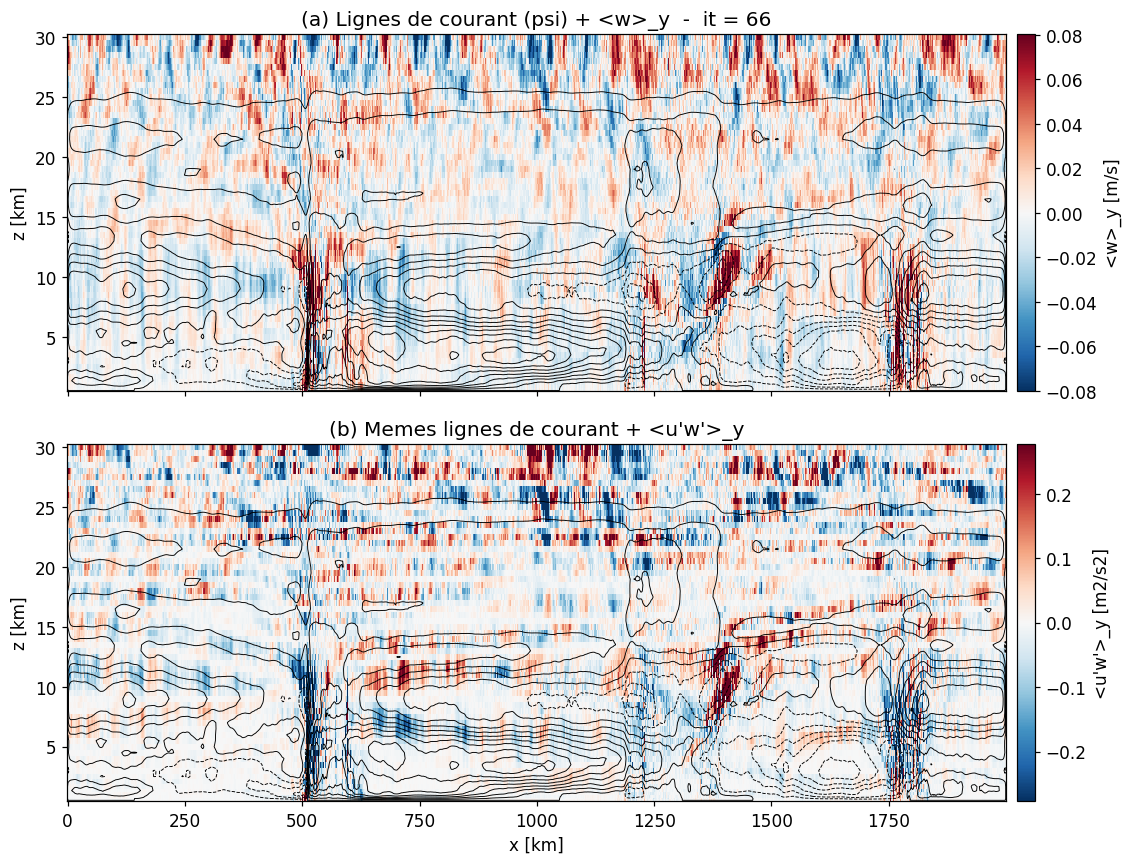

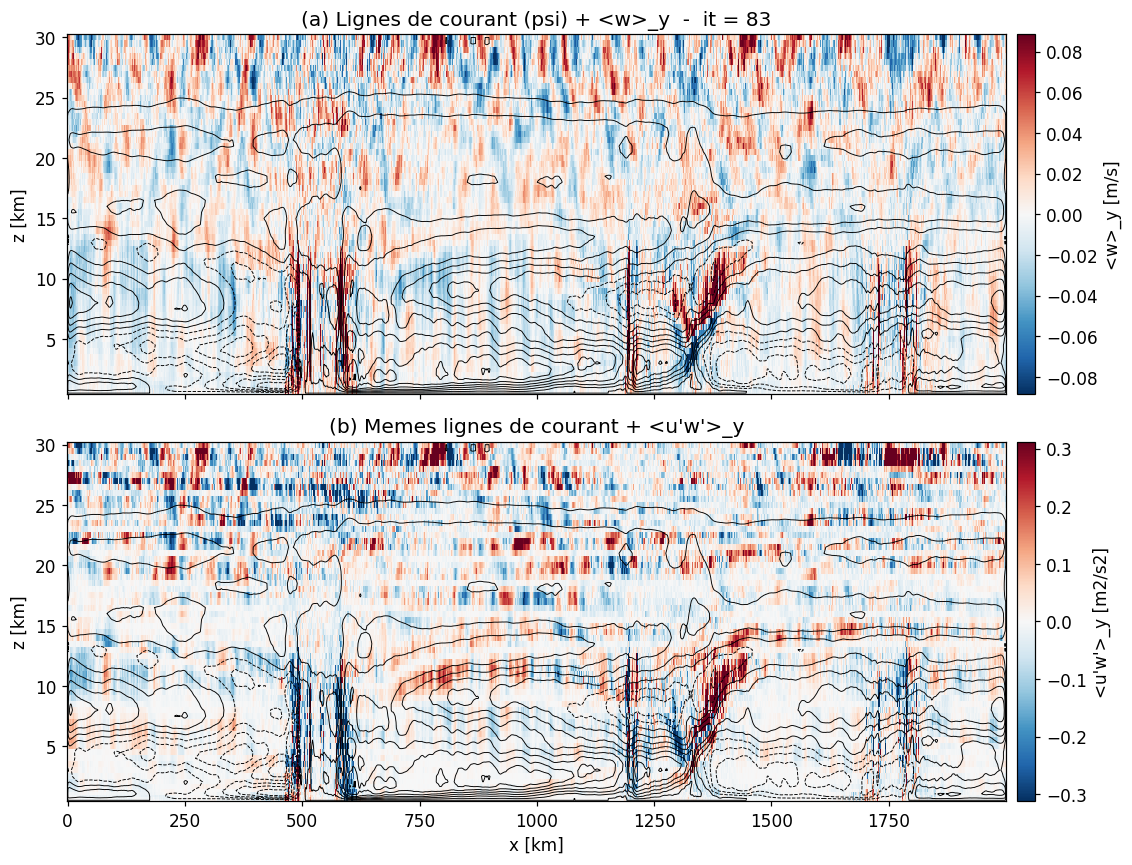

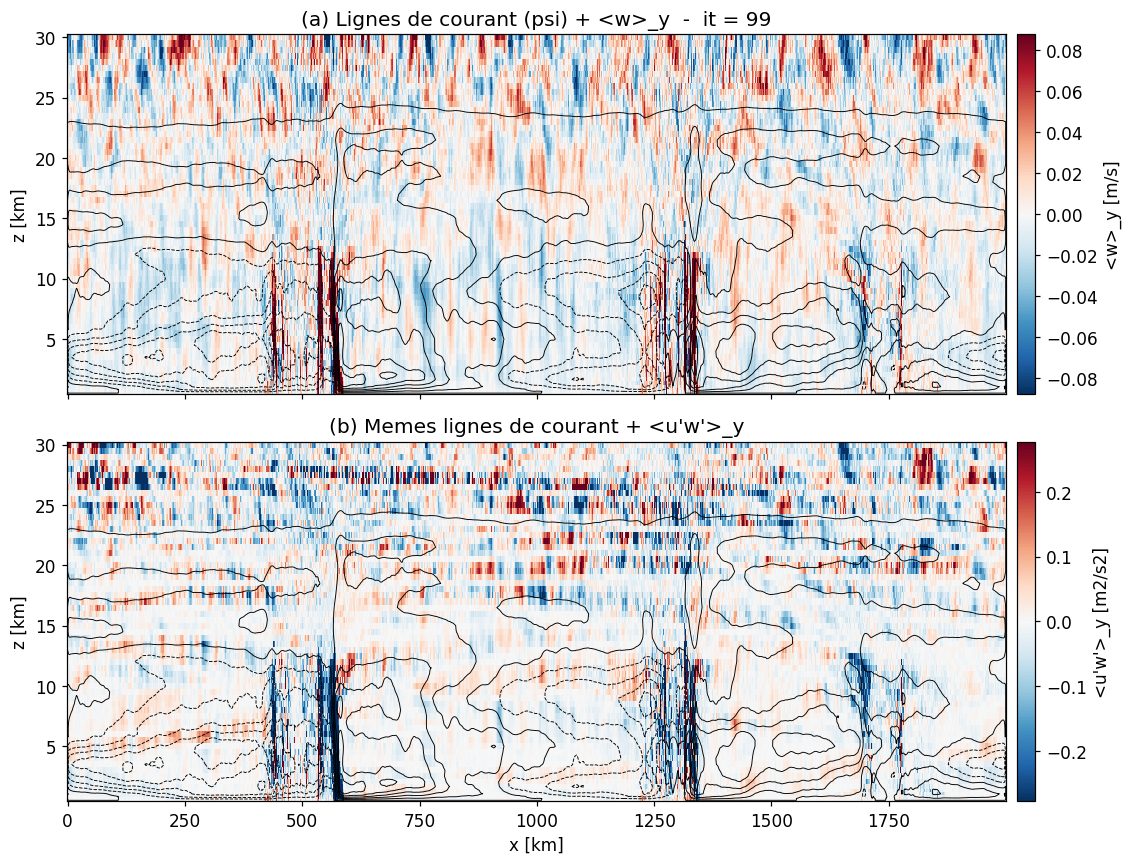

In [ ]:
# ======================================================================
#  Coupes (z,x) à des instants t donnés — moyennées sur y SEULEMENT
#  Version autonome : ne dépend que de dim_t, dim_z, dim_x, n_t, n_x,
#  alt, t_stat, n_stat, x, path3d. Recalcule rho0 et tout le reste.
# ======================================================================
from scipy.sparse import diags, kron, identity
from scipy.sparse.linalg import spsolve

ZMIN, ZMAX = 500., 30000.
T_SNAPS = [t_stat, t_stat + n_stat//2, n_t - 1]   # instants à tracer

# --- rho0 sur la grille COMPLETE (au cas où il aurait été tronqué ailleurs) ---
_nz_full = alt.size
rho0_full = np.zeros(_nz_full); _nr = 0
_da = xr.open_dataset(path3d('ta')); _dp = xr.open_dataset(path3d('pa')); _dh = xr.open_dataset(path3d('hus'))
for t0 in range(t_stat, n_t, BLOC):
    t1 = min(t0+BLOC, n_t); sl = {dim_t: slice(t0,t1)}
    T = _da['ta'].isel(sl).values; P = _dp['pa'].isel(sl).values; Q = _dh['hus'].isel(sl).values
    Tv = T*(1.0+Q/EPSILON)/(1.0+Q)
    rho0_full += (P/(Rd*Tv)).mean(axis=(0,2,3))*(t1-t0); _nr += (t1-t0)
    del T,P,Q,Tv; gc.collect()
_da.close(); _dp.close(); _dh.close(); del _da,_dp,_dh; gc.collect()
rho0_full /= _nr

kz = (alt >= ZMIN) & (alt <= ZMAX)        # masque vertical 2-18 km

def coupe_instant(it):
    U_i = np.zeros((_nz_full, n_x)); W_i = np.zeros((_nz_full, n_x)); UP_i = np.zeros((_nz_full, n_x))
    du = xr.open_dataset(path3d('ua')); dw = xr.open_dataset(path3d('wa'))
    for iz in range(_nz_full):
        u_yx = du['ua'].isel({dim_t: it, dim_z: iz}).values
        w_yx = dw['wa'].isel({dim_t: it, dim_z: iz}).values
        u_p = u_yx - u_yx.mean(); w_p = w_yx - w_yx.mean()
        U_i[iz] = u_yx.mean(axis=0); W_i[iz] = w_yx.mean(axis=0)
        UP_i[iz] = (u_p*w_p).mean(axis=0)
        del u_yx, w_yx, u_p, w_p
    du.close(); dw.close(); del du, dw; gc.collect()
    return alt[kz], rho0_full[kz], U_i[kz], W_i[kz], UP_i[kz]

def psi_poisson(U_i, W_i, x, z_i, rho_i):
    nz, nx = U_i.shape
    dxl = float(x[1]-x[0]); dzl = float(z_i[1]-z_i[0])
    rhoU = rho_i[:,None]*U_i; rhoW = rho_i[:,None]*W_i
    omega = np.gradient(rhoW, dxl, axis=1) - np.gradient(rhoU, dzl, axis=0)
    Ix = identity(nx-2); Iz = identity(nz-2)
    Lx = diags([1.,-2.,1.],[-1,0,1],shape=(nx-2,nx-2))/dxl**2
    Lz = diags([1.,-2.,1.],[-1,0,1],shape=(nz-2,nz-2))/dzl**2
    A = (kron(Iz,Lx)+kron(Lz,Ix)).tocsr()
    psi = np.zeros((nz,nx))
    psi[1:-1,1:-1] = spsolve(A, omega[1:-1,1:-1].ravel()).reshape(nz-2,nx-2)
    return psi

for it in T_SNAPS:
    z_i, rho_i, U_i, W_i, UP_i = coupe_instant(it)
    psi_i = psi_poisson(U_i, W_i, x, z_i, rho_i)
    Xkm, Zkm = x/1000, z_i/1000

    fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
    ax = axes[0]
    wmax = np.percentile(np.abs(W_i), 99) + 1e-12
    pc = ax.pcolormesh(Xkm, Zkm, W_i, shading='auto',
                       norm=TwoSlopeNorm(vcenter=0, vmin=-wmax, vmax=wmax), cmap='RdBu_r')
    ax.contour(Xkm, Zkm, psi_i, levels=14, colors='k', linewidths=0.6)
    ax.set_title(f"(a) Lignes de courant (psi) + <w>_y  -  it = {it}")
    ax.set_ylabel('z [km]'); fig.colorbar(pc, ax=ax, label='<w>_y [m/s]', pad=0.01)

    ax = axes[1]
    fmax = np.percentile(np.abs(UP_i), 98) + 1e-12
    pc = ax.pcolormesh(Xkm, Zkm, UP_i, shading='auto',
                       norm=TwoSlopeNorm(vcenter=0, vmin=-fmax, vmax=fmax), cmap='RdBu_r')
    ax.contour(Xkm, Zkm, psi_i, levels=14, colors='k', linewidths=0.6)
    ax.set_title("(b) Memes lignes de courant + <u'w'>_y")
    ax.set_xlabel('x [km]'); ax.set_ylabel('z [km]')
    fig.colorbar(pc, ax=ax, label="<u'w'>_y [m2/s2]", pad=0.01)
    plt.tight_layout(); plt.show()

/tmp/ipykernel_44627/2023836086.py:61: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pc = ax.pcolormesh(Xkm, Zkm, W_i, shading='auto',
/tmp/ipykernel_44627/2023836086.py:69: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pc = ax.pcolormesh(Xkm, Zkm, UP_i, shading='auto',


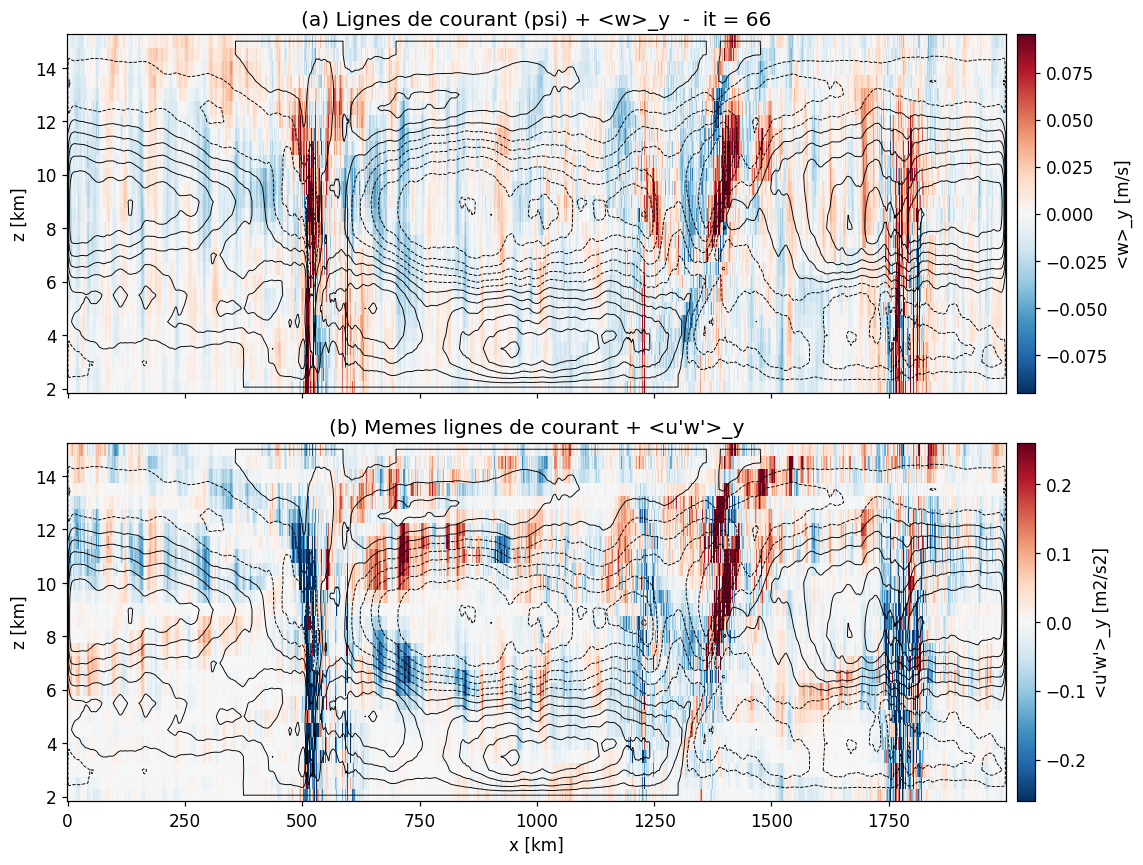

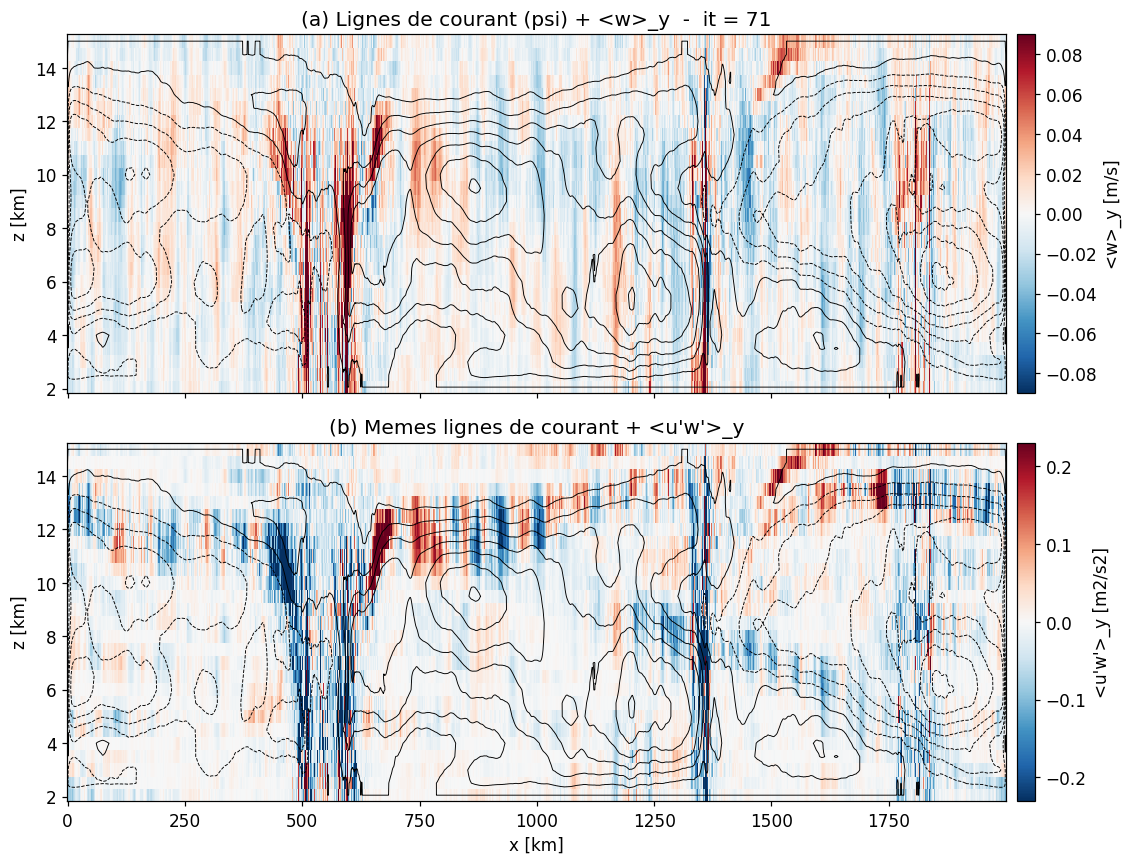

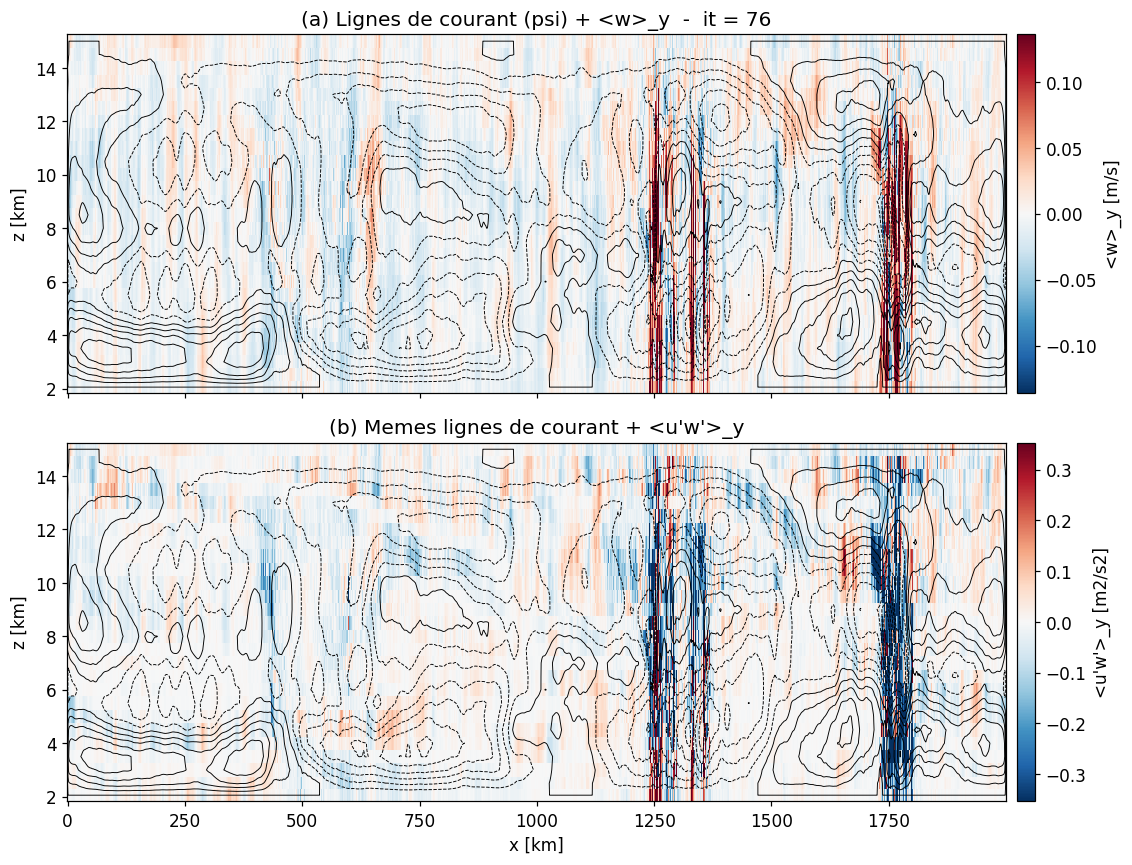

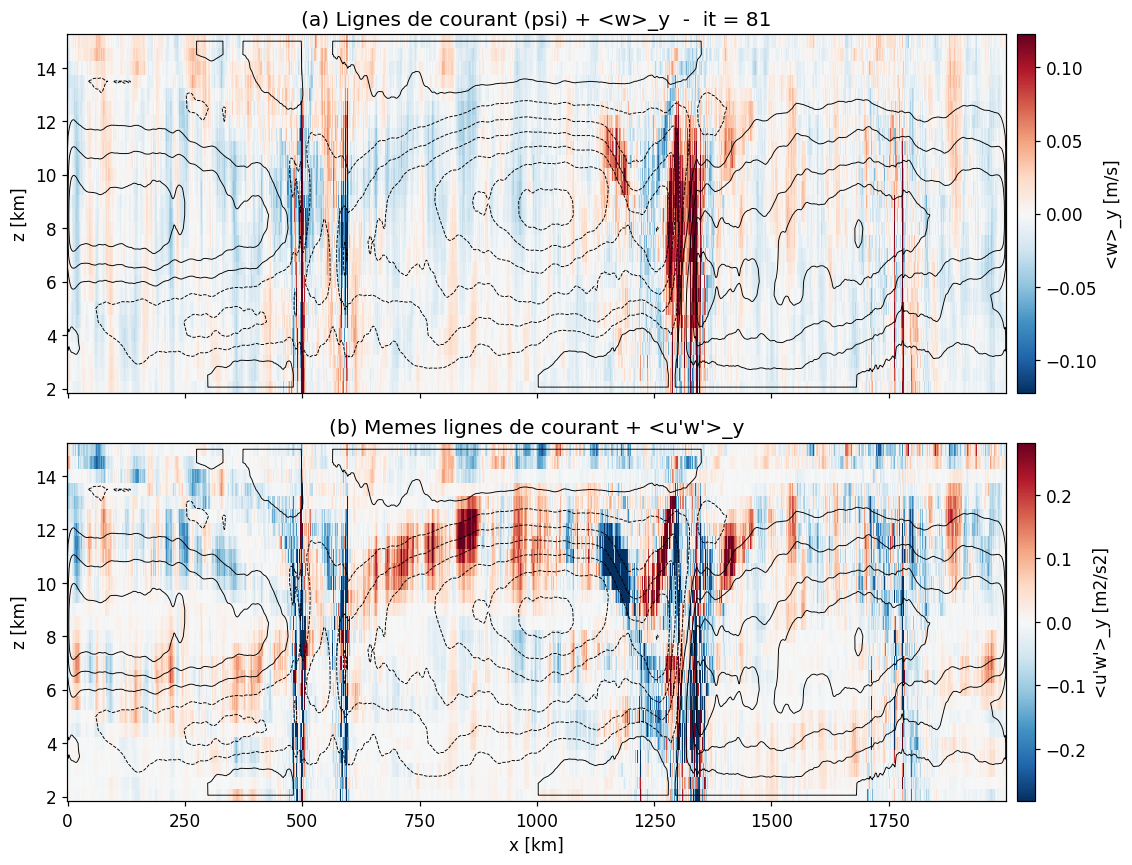

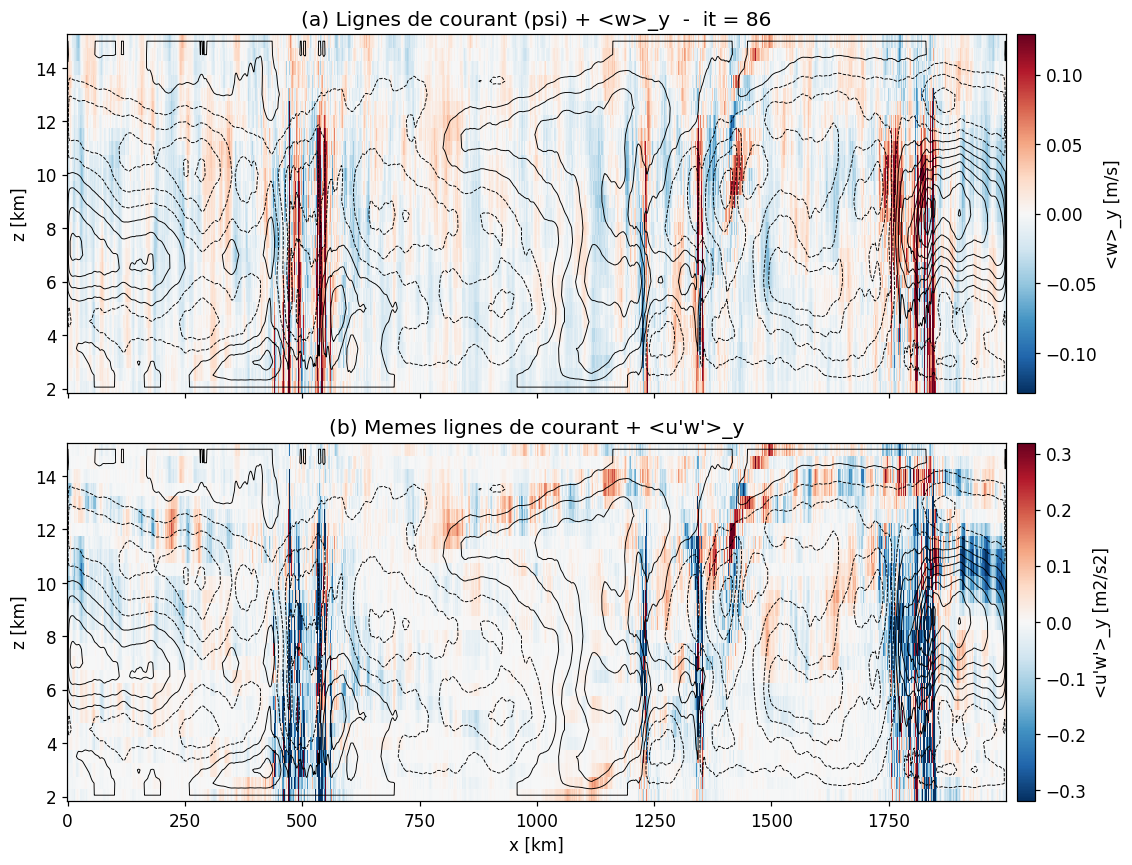

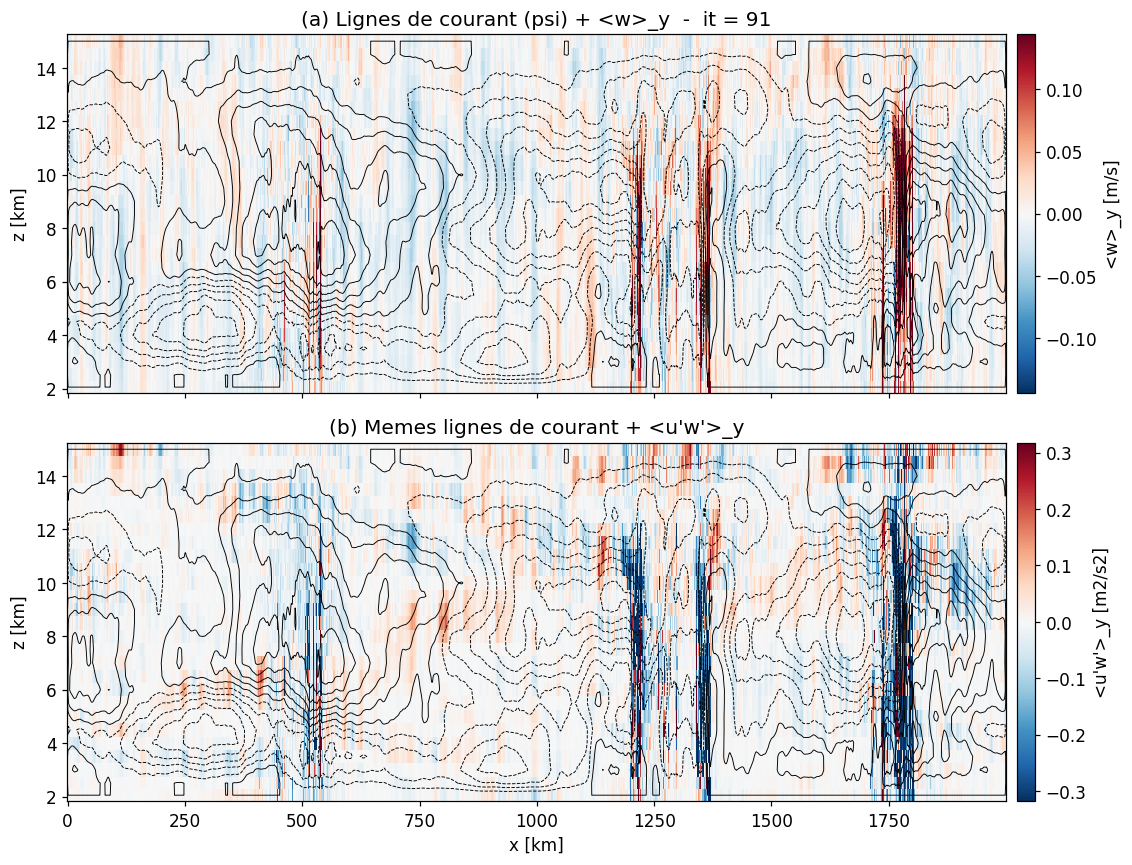

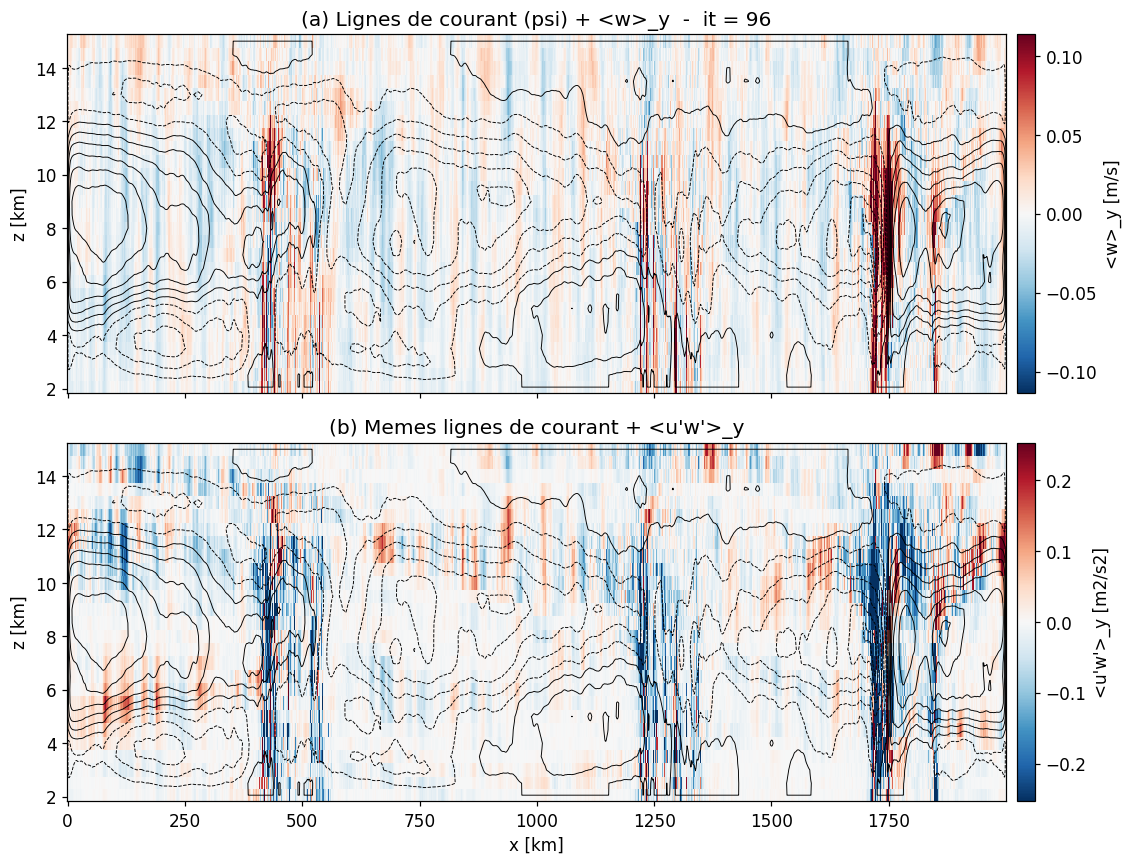

In [ ]:
# ======================================================================
#  Coupes (z,x) à des instants t donnés — moyennées sur y SEULEMENT
#  Version autonome : ne dépend que de dim_t, dim_z, dim_x, n_t, n_x,
#  alt, t_stat, n_stat, x, path3d. Recalcule rho0 et tout le reste.
# ======================================================================
from scipy.sparse import diags, kron, identity
from scipy.sparse.linalg import spsolve

ZMIN, ZMAX = 2000., 15000.
T_SNAPS = list(range(t_stat, n_t, 5))   # instants à tracer

# --- rho0 sur la grille COMPLETE (au cas où il aurait été tronqué ailleurs) ---
_nz_full = alt.size
rho0_full = np.zeros(_nz_full); _nr = 0
_da = xr.open_dataset(path3d('ta')); _dp = xr.open_dataset(path3d('pa')); _dh = xr.open_dataset(path3d('hus'))
for t0 in range(t_stat, n_t, BLOC):
    t1 = min(t0+BLOC, n_t); sl = {dim_t: slice(t0,t1)}
    T = _da['ta'].isel(sl).values; P = _dp['pa'].isel(sl).values; Q = _dh['hus'].isel(sl).values
    Tv = T*(1.0+Q/EPSILON)/(1.0+Q)
    rho0_full += (P/(Rd*Tv)).mean(axis=(0,2,3))*(t1-t0); _nr += (t1-t0)
    del T,P,Q,Tv; gc.collect()
_da.close(); _dp.close(); _dh.close(); del _da,_dp,_dh; gc.collect()
rho0_full /= _nr

kz = (alt >= ZMIN) & (alt <= ZMAX)        # masque vertical 2-18 km

def coupe_instant(it):
    U_i = np.zeros((_nz_full, n_x)); W_i = np.zeros((_nz_full, n_x)); UP_i = np.zeros((_nz_full, n_x))
    du = xr.open_dataset(path3d('ua')); dw = xr.open_dataset(path3d('wa'))
    for iz in range(_nz_full):
        u_yx = du['ua'].isel({dim_t: it, dim_z: iz}).values
        w_yx = dw['wa'].isel({dim_t: it, dim_z: iz}).values
        u_p = u_yx - u_yx.mean(); w_p = w_yx - w_yx.mean()
        U_i[iz] = u_yx.mean(axis=0); W_i[iz] = w_yx.mean(axis=0)
        UP_i[iz] = (u_p*w_p).mean(axis=0)
        del u_yx, w_yx, u_p, w_p
    du.close(); dw.close(); del du, dw; gc.collect()
    return alt[kz], rho0_full[kz], U_i[kz], W_i[kz], UP_i[kz]

def psi_poisson(U_i, W_i, x, z_i, rho_i):
    nz, nx = U_i.shape
    dxl = float(x[1]-x[0]); dzl = float(z_i[1]-z_i[0])
    rhoU = rho_i[:,None]*U_i; rhoW = rho_i[:,None]*W_i
    omega = np.gradient(rhoW, dxl, axis=1) - np.gradient(rhoU, dzl, axis=0)
    Ix = identity(nx-2); Iz = identity(nz-2)
    Lx = diags([1.,-2.,1.],[-1,0,1],shape=(nx-2,nx-2))/dxl**2
    Lz = diags([1.,-2.,1.],[-1,0,1],shape=(nz-2,nz-2))/dzl**2
    A = (kron(Iz,Lx)+kron(Lz,Ix)).tocsr()
    psi = np.zeros((nz,nx))
    psi[1:-1,1:-1] = spsolve(A, omega[1:-1,1:-1].ravel()).reshape(nz-2,nx-2)
    return psi

for it in T_SNAPS:
    z_i, rho_i, U_i, W_i, UP_i = coupe_instant(it)
    psi_i = psi_poisson(U_i, W_i, x, z_i, rho_i)
    Xkm, Zkm = x/1000, z_i/1000

    fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
    ax = axes[0]
    wmax = np.percentile(np.abs(W_i), 99) + 1e-12
    pc = ax.pcolormesh(Xkm, Zkm, W_i, shading='auto',
                       norm=TwoSlopeNorm(vcenter=0, vmin=-wmax, vmax=wmax), cmap='RdBu_r')
    ax.contour(Xkm, Zkm, psi_i, levels=14, colors='k', linewidths=0.6)
    ax.set_title(f"(a) Lignes de courant (psi) + <w>_y  -  it = {it}")
    ax.set_ylabel('z [km]'); fig.colorbar(pc, ax=ax, label='<w>_y [m/s]', pad=0.01)

    ax = axes[1]
    fmax = np.percentile(np.abs(UP_i), 98) + 1e-12
    pc = ax.pcolormesh(Xkm, Zkm, UP_i, shading='auto',
                       norm=TwoSlopeNorm(vcenter=0, vmin=-fmax, vmax=fmax), cmap='RdBu_r')
    ax.contour(Xkm, Zkm, psi_i, levels=14, colors='k', linewidths=0.6)
    ax.set_title("(b) Memes lignes de courant + <u'w'>_y")
    ax.set_xlabel('x [km]'); ax.set_ylabel('z [km]')
    fig.colorbar(pc, ax=ax, label="<u'w'>_y [m2/s2]", pad=0.01)
    plt.tight_layout(); plt.show()

## 4. Que tirer de la visualisation ? — diagnostics sur le dernier pas de temps

Colocalisation circulation/flux : r = -0.001
  (proche de 0 => le flux n'est PAS là où la masse circule)
80% du flux |u'w'| est porté par 32.7% de la surface
  (petit => flux ultra-localisé, incompatible avec un mass-flux étalé)


/tmp/ipykernel_44627/2583971188.py:35: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  m0 = ax[0].pcolormesh(x/1000, z/1000, speed_masse, shading='auto', cmap='viridis')
/tmp/ipykernel_44627/2583971188.py:41: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  m1 = ax[1].pcolormesh(x/1000, z/1000, flux_abs, shading='auto', cmap='magma')


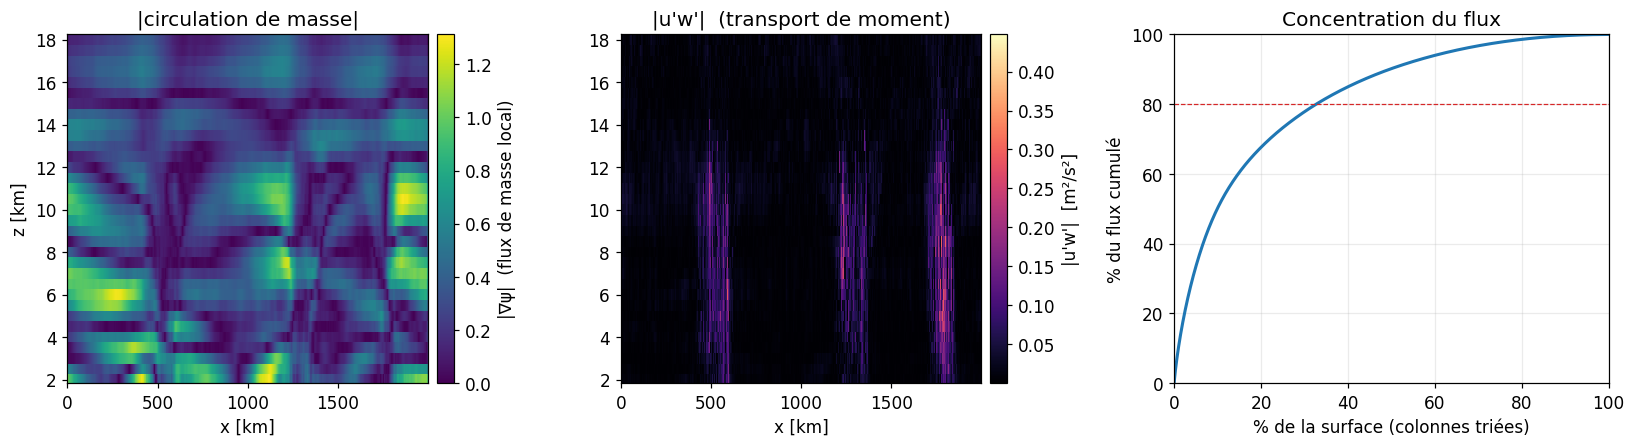

In [ ]:
# ====================================================================
#  Diagnostics ANCRÉS sur la visualisation (coupes z,x de cette section)
#  Idée : quantifier ce que l'œil voit — la circulation de masse (psi)
#  et le flux u'w' n'occupent PAS les mêmes endroits du plan (x,z).
# ====================================================================

# 1) Intensité de la circulation de masse = |gradient de psi| (vitesse de masse locale)
dpsidz, dpsidx = np.gradient(psi, z, x)        # psi = ta fonction de courant tracée
speed_masse = np.hypot(dpsidx, dpsidz)         # |flux de masse| en chaque (z,x)

# 2) Intensité du transport de moment = |u'w'| local
flux_abs = np.abs(upwp)

# --- Colocalisation : corrélation spatiale entre les deux cartes ---
a = speed_masse.ravel(); b = flux_abs.ravel()
a = a - a.mean(); b = b - b.mean()
coloc = (a*b).sum() / (np.sqrt((a**2).sum()*(b**2).sum()) + 1e-30)
print(f"Colocalisation circulation/flux : r = {coloc:+.3f}")
print("  (proche de 0 => le flux n'est PAS là où la masse circule)")

# --- Concentration du flux : quelle fraction de surface porte le flux ? ---
f_sorted = np.sort(flux_abs.ravel())[::-1]
cum = np.cumsum(f_sorted) / f_sorted.sum()
frac_surface = np.arange(1, f_sorted.size+1) / f_sorted.size
seuil80 = frac_surface[np.searchsorted(cum, 0.80)]
print(f"80% du flux |u'w'| est porté par {seuil80*100:.1f}% de la surface")
print("  (petit => flux ultra-localisé, incompatible avec un mass-flux étalé)")

# ====================================================================
#  Figure : les deux cartes côte à côte + courbe de concentration
# ====================================================================
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

# carte 1 : intensité de la circulation de masse
m0 = ax[0].pcolormesh(x/1000, z/1000, speed_masse, shading='auto', cmap='viridis')
ax[0].set_title("|circulation de masse|")
ax[0].set_xlabel('x [km]'); ax[0].set_ylabel('z [km]')
fig.colorbar(m0, ax=ax[0], label='|∇ψ|  (flux de masse local)', pad=0.02)

# carte 2 : intensité du flux de moment
m1 = ax[1].pcolormesh(x/1000, z/1000, flux_abs, shading='auto', cmap='magma')
ax[1].set_title("|u'w'|  (transport de moment)")
ax[1].set_xlabel('x [km]')
fig.colorbar(m1, ax=ax[1], label="|u'w'|  [m²/s²]", pad=0.02)

# graphe 3 : courbe de concentration (pas de colorbar, c'est une courbe)
ax[2].plot(frac_surface*100, cum*100, lw=2)
ax[2].axhline(80, color='C3', ls='--', lw=0.8)
ax[2].set_xlabel('% de la surface (colonnes triées)')
ax[2].set_ylabel('% du flux cumulé')
ax[2].set_title('Concentration du flux')
ax[2].set_xlim(0, 100); ax[2].set_ylim(0, 100)

plt.tight_layout(); plt.show()